
# ==========================================================
#  STUDY
# ==========================================================
# 
# Scientific Question:
# What is the reproducibility of instrumental angular velocity during passive elbow extension in healthy subjects?
#
#
# Hypothesis:
# Instrumental biomechanical parameters show good intra-session  reproducibility in healthy subjects.
#
# Author: [Anaïs RAGON + Co Pilot]
# Date: [12/05/2026]
# ==========================================================

# Part 1 — Data Parsing & Angle Computation

## Objective
Load raw IMU sensor files, extract quaternion data from two sensors
(wrist and shoulder), and compute elbow flexion/extension angles over time.

## Inputs
- Raw CSV files per patient and side (`Data_[ID]_D.csv` / `Data_[ID]_G.csv`)
- Each file contains two data blocks: **K-Push** (force sensor) and **K-Move** (IMU quaternions)
- A baseline quaternion per sensor, recorded at a known reference angle (30°)

## Method
1. Files are parsed to separate the K-Push and K-Move blocks
2. Quaternion data is extracted for both the wrist (`S121577`) and shoulder (`S121578`) sensors
3. Each quaternion is normalized and compared to its baseline using relative rotation
4. The elbow angle is derived from the relative quaternion using the standard pitch formula
5. Angles are unwrapped, zeroed at start, and offset by the baseline angle (30°)

## Outputs
- `df_angles`: a time-series DataFrame with columns `time` and `angle` (degrees)
- One curve per patient × side combination


Patient: P01 (Ch)

===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
right: 18.4° → 190.2°


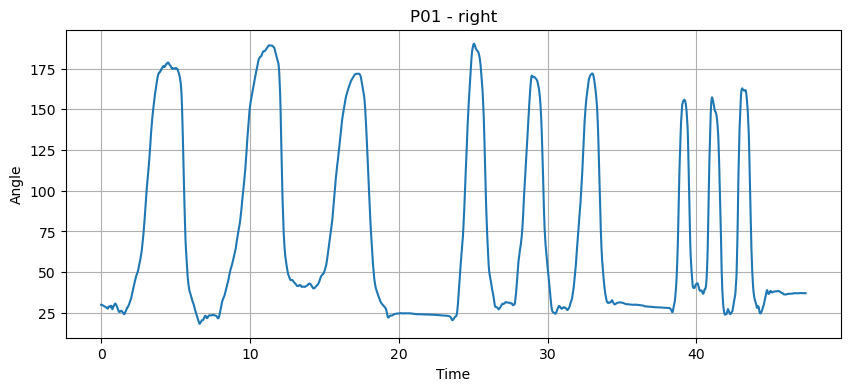


===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873
1  0.001  0.3454
2  0.002  0.4057
3  0.003  0.4267
4  0.004  0.4324

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.238220  0.542358  0.726257  0.348633
1  0.004  0.238228  0.542376  0.726250  0.348674
2  0.008  0.238227  0.542373  0.726216  0.348764
3  0.012  0.238227  0.542344  0.726188  0.348857
4  0.016  0.238259  0.542317  0.726161  0.348920

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.526794 -0.283691 -0.028687  0.800720
1  0.004 -0.526864 -0.283604 -0.028748  0.800703
2  0.008 -0.526988 -0.283423 -0.028840  0.800676
3  0.012 -0.527083 -0.283302 -0.028870  0.800649
4  0.016 -0.527146 -0.283242 -0.028871  0.800623

Baseline wrist: [0.322, 0.519, 0.689, 0.39]
Baseline shoulder: [-0.515, -0.288, -0.043, 0.806]

Shapes: (47023, 2) (11751, 5) (11751, 5)
left: -11.2° → 193.1°


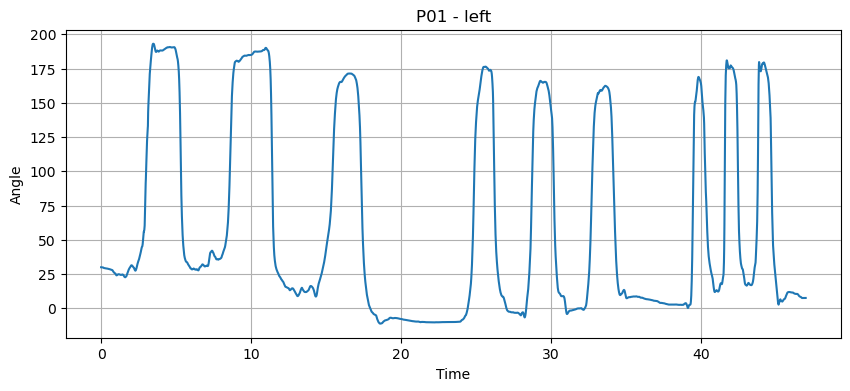


Patient: P02 (Lo)

===== FILE: Data_Lo_D.csv =====
K-Push:
     time   force
0  0.000  0.4864
1  0.001  0.4776
2  0.002  0.4503
3  0.003  0.4519
4  0.004  0.4711

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.476135  0.443481  0.257568  0.714233
1  0.004  0.476059  0.443648  0.257607  0.714226
2  0.008  0.475903  0.443951  0.257666  0.714130
3  0.012  0.475748  0.444284  0.257665  0.714034
4  0.016  0.475593  0.444586  0.257633  0.713969

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.492126  0.111816 -0.044678  0.862122
1  0.004 -0.492139  0.111880 -0.044679  0.862112
2  0.008 -0.492142  0.111973 -0.044710  0.862088
3  0.012 -0.492168  0.112002 -0.044740  0.862079
4  0.016 -0.492228  0.112002 -0.044770  0.862047

Baseline wrist: [0.446, 0.468, 0.205, 0.735]
Baseline shoulder: [-0.482, 0.116, -0.05, 0.867]

Shapes: (50000, 2) (12505, 5) (12505, 5)
right: 6.3° → 212.9°


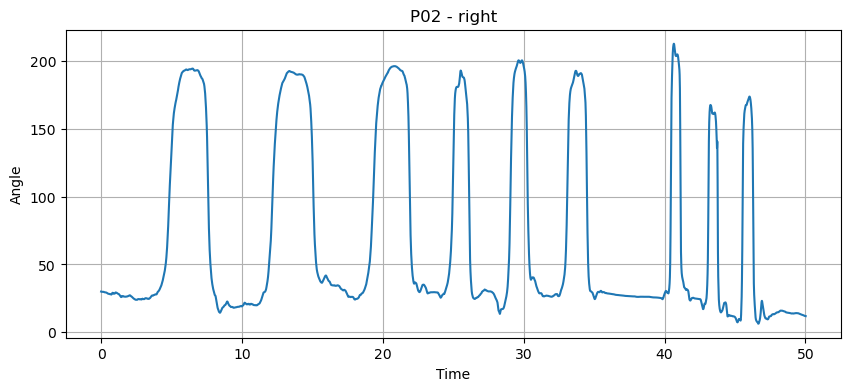


===== FILE: Data_Lo_G.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.391357  0.506592  0.608215  0.469177
1  0.004  0.389633  0.507557  0.608971  0.468676
2  0.008  0.386273  0.509354  0.610492  0.467543
3  0.012  0.383216  0.510934  0.612101  0.466255
4  0.016  0.380499  0.512276  0.613718  0.464882

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.521973 -0.042358 -0.137146  0.840759
1  0.004 -0.521919 -0.042084 -0.137301  0.840802
2  0.008 -0.521742 -0.041566 -0.137607  0.840873
3  0.012 -0.521472 -0.041017 -0.137944  0.841003
4  0.016 -0.521195 -0.040498 -0.138279  0.841151

Baseline wrist: [0.356, 0.536, 0.595, 0.481]
Baseline shoulder: [-0.505, -0.063, -0.189, 0.84]

Shapes: (46802, 2) (11711, 5) (11711, 5)
left: 12.5° → 173.6°


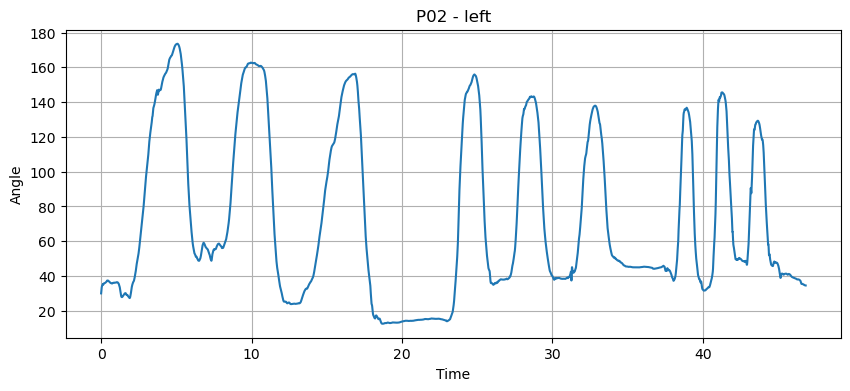


Patient: P03 (Ca)

===== FILE: Data_Ca_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.379578  0.572693  0.419983  0.592834
1  0.004  0.379433  0.572857  0.419992  0.592816
2  0.008  0.379190  0.573073  0.419993  0.592757
3  0.012  0.379011  0.573232  0.420028  0.592672
4  0.016  0.378830  0.573388  0.420092  0.592584

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.504944  0.146362 -0.121033  0.841919
1  0.004 -0.504653  0.146366 -0.121341  0.842095
2  0.008 -0.504195  0.146397 -0.121708  0.842309
3  0.012 -0.503982  0.146458 -0.121677  0.842431
4  0.016 -0.503982  0.146611 -0.121677  0.842402

Baseline wrist: [0.423, 0.515, 0.376, 0.644]
Baseline shoulder: [-0.481, 0.16, -0.099, 0.856]

Shapes: (48244, 2) (12066, 5) (12066, 5)
right: 14.1° → 203.3°


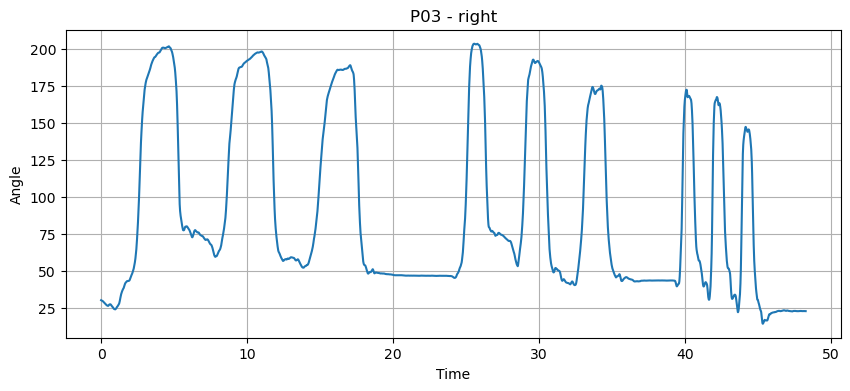


===== FILE: Data_Ca_G.csv =====
K-Push:
     time   force
0  0.000  0.3518
1  0.001  0.3762
2  0.002  0.3133
3  0.003  0.3495
4  0.004  0.3614

Wrist:
     time        qx        qy        qz        qw
0  0.000 -0.404846  0.490967 -0.480042  0.603699
1  0.004 -0.404831  0.491016 -0.480060  0.603722
2  0.008 -0.404796  0.491072 -0.480024  0.603746
3  0.012 -0.404762  0.491128 -0.479989  0.603770
4  0.016 -0.404702  0.491161 -0.479991  0.603773

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.537476 -0.038086 -0.139587  0.830688
1  0.004 -0.537495 -0.038057 -0.139592  0.830718
2  0.008 -0.537489 -0.037995 -0.139591  0.830739
3  0.012 -0.537483 -0.037934 -0.139589  0.830760
4  0.016 -0.537483 -0.037903 -0.139589  0.830761

Baseline wrist: [-0.456, 0.424, -0.421, 0.66]
Baseline shoulder: [-0.52, -0.036, -0.194, 0.831]

Shapes: (44759, 2) (11185, 5) (11185, 5)
left: 26.3° → 184.4°


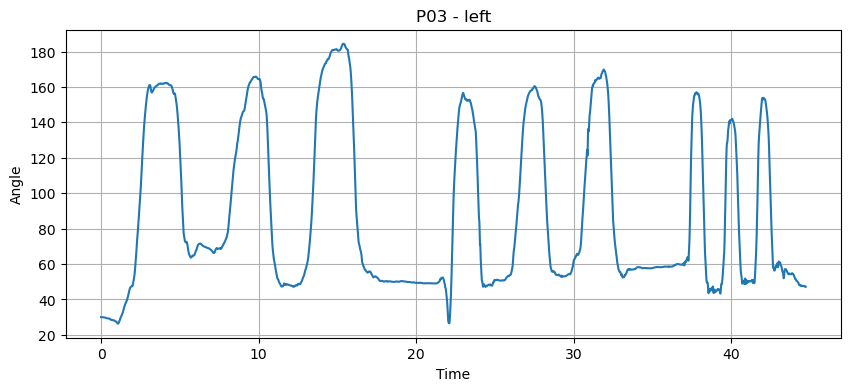

In [30]:
# ==========================================================
# PASSIVE ELBOW EXTENSION – ANGLE ANALYSIS
# ==========================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

warnings.filterwarnings('ignore')

# ==========================================================
# PATIENT CONFIGURATION
# ==========================================================

PATIENTS = {
    "P01": {"id": "Ch", "right": "Data_Ch_D.csv", "left": "Data_Ch_G.csv"},
    "P02": {"id": "Lo", "right": "Data_Lo_D.csv", "left": "Data_Lo_G.csv"},
    "P03": {"id": "Ca", "right": "Data_Ca_D.csv", "left": "Data_Ca_G.csv"},
}

# ==========================================================
# FILE LOADING
# ==========================================================

def load_data(filename):
    for base_dir in [os.path.join("..", "data"), os.path.join(".", "data"), "."]:
        path = os.path.join(base_dir, filename)
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")

# ==========================================================
# FILE PARSING
# ==========================================================

def process_file(filename):

    lines = load_data(filename)

    idx_push = next(i for i, l in enumerate(lines) if "K-Push" in l)
    idx_move = next(i for i, l in enumerate(lines) if "K-Move" in l)

    if idx_push < idx_move:
        push_lines, move_lines = lines[idx_push:idx_move], lines[idx_move:]
    else:
        push_lines, move_lines = lines[idx_push:], lines[idx_move:idx_push]

    # --- K-Push ---
    header_push = next(i for i, l in enumerate(push_lines) if "temps" in l)
    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_push:])),
        sep=r"\t|,", engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # --- Baseline ---
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t") if "\t" in line else line.strip().split(",")
            values = [float(x) for x in parts[1:] if _is_float(x)][:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # --- K-Move ---
    header_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = [
        (l.strip().split("\t") if "\t" in l else l.strip().split(","))
        for l in move_lines[header_move + 1:]
    ]

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()

    for df in [df_wrist, df_shoulder]:
        df.columns = ["time", "qx", "qy", "qz", "qw"]

    # ✅ PRINT ICI (correctement placé)
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


def _is_float(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

# ==========================================================
# QUATERNION
# ==========================================================

def quat_conjugate(q):
    return np.array([-q[0], -q[1], -q[2], q[3]])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize(q):
    return q / np.linalg.norm(q)

# ==========================================================
# ANGLE
# ==========================================================

def compute_angle(df_quat, baseline_quat, baseline_deg=30):

    q_base_inv = quat_conjugate(normalize(np.array(baseline_quat)))

    angles = []

    for i in range(len(df_quat)):
        q = normalize(np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ]))

        q_rel = quat_multiply(q_base_inv, q)

        qx, qy, qz, qw = q_rel

        angle = np.arctan2(2*(qw*qy + qx*qz), 1 - 2*(qy**2 + qz**2))
        angles.append(angle)

    angles = np.degrees(np.unwrap(angles))
    angles -= angles[0]

    if np.mean(angles) < 0:
        angles = -angles

    angles += baseline_deg

    return df_quat[["time"]].assign(angle=angles)

# ==========================================================
# MAIN
# ==========================================================

all_angles = {}

for p_name, p_info in PATIENTS.items():

    print(f"\n{'='*40}\nPatient: {p_name} ({p_info['id']})\n{'='*40}")

    all_angles[p_name] = {}

    for side in ["right", "left"]:

        try:
            df_push, df_wrist, df_shoulder, baseline = process_file(p_info[side])
        except FileNotFoundError as e:
            print(f"[WARNING] {e}")
            continue

        if len(baseline["wrist"]) != 4:
            print(f"[WARNING] Missing baseline for {p_name}/{side}")
            continue

        df_angles = compute_angle(df_wrist, baseline["wrist"])
        all_angles[p_name][side] = df_angles

        print(f"{side}: {df_angles['angle'].min():.1f}° → {df_angles['angle'].max():.1f}°")

        plt.figure(figsize=(10,4))
        plt.plot(df_angles["time"], df_angles["angle"])
        plt.title(f"{p_name} - {side}")
        plt.xlabel("Time")
        plt.ylabel("Angle")
        plt.grid()
        plt.show()

# Part 2 — Event Detection & Velocity Analysis

## Objective
Automatically detect extension peaks and flexion troughs in the filtered angle signal,
then compute angular velocity for each movement trial and categorize trials by speed.

## Inputs
- `df_angles`: angle time-series from Part 1 (columns: `time`, `angle`)
- Global parameters: filter cutoff (10 Hz), min peak prominence (15°),
  min distance between peaks (1.5 s), max peaks/troughs (N_MAX=9, N_MIN=10)

## Method
1. A 4th-order Butterworth low-pass filter (zero-phase, `filtfilt`) smooths the signal
2. `find_peaks` detects extension peaks; troughs are found as local minima between consecutive peaks
3. Each extension trial is characterized by its duration, amplitude, and mean angular velocity (°/s)
4. Trials are labeled by speed category: **slow** (trials 1–3), **medium** (4–6), **fast** (7–9)
5. Velocity profiles are extracted per trial for reproducibility visualization

## Outputs
- `resultats`: nested dict storing filtered signal, peak/trough indices per patient × side
- `df_full` (via `all_events_long`): one row per trial with columns
  `subject`, `side`, `speed`, `trial`, `velocity`
- Reproducibility plots: velocity curves superimposed per speed category


=== DETECTION: P01 | RIGHT ===


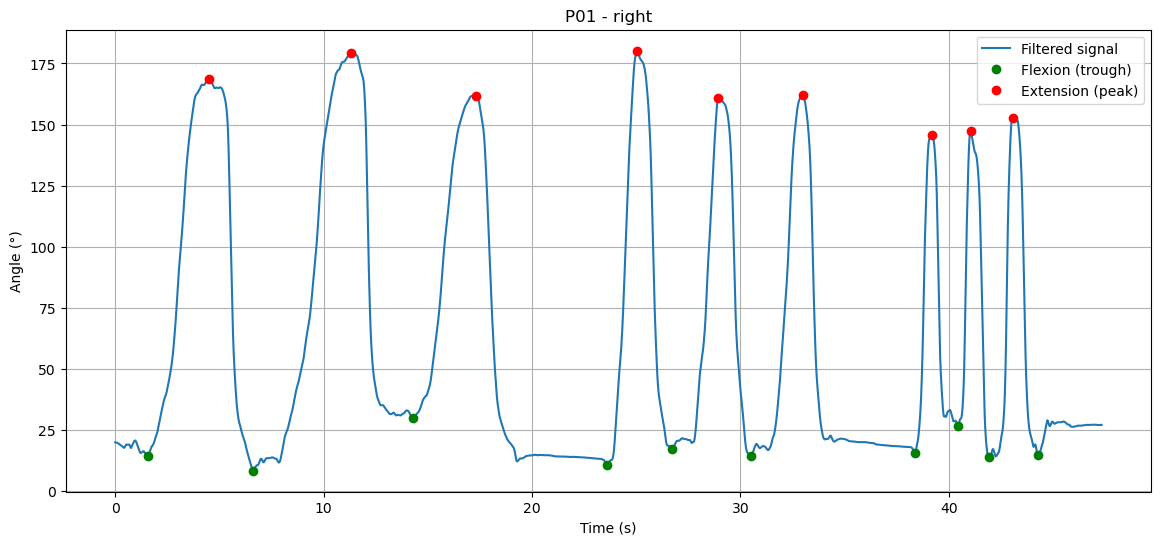


=== DETECTION: P01 | LEFT ===


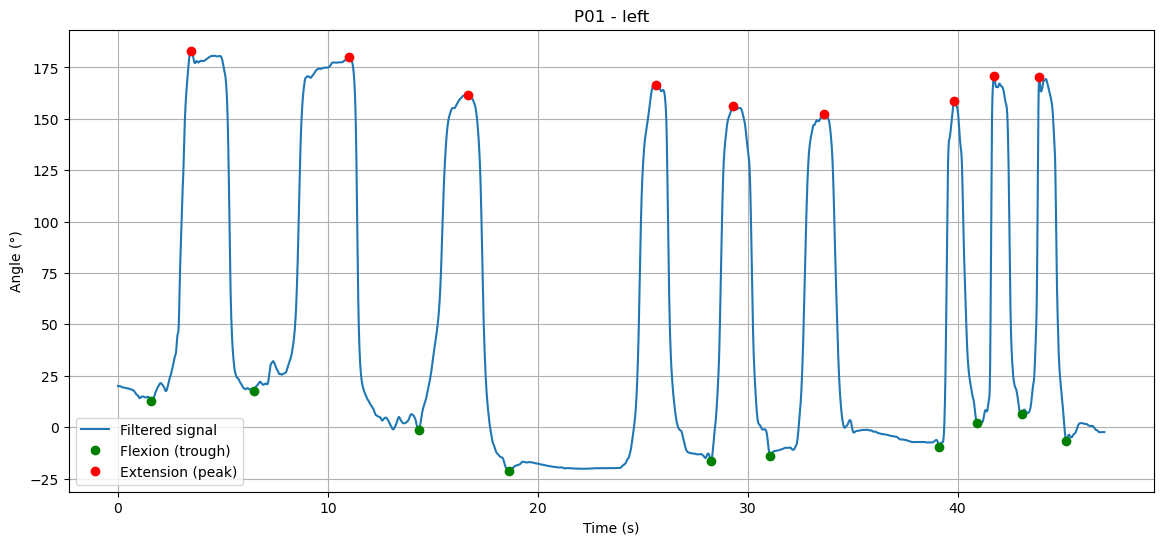


=== DETECTION: P02 | RIGHT ===


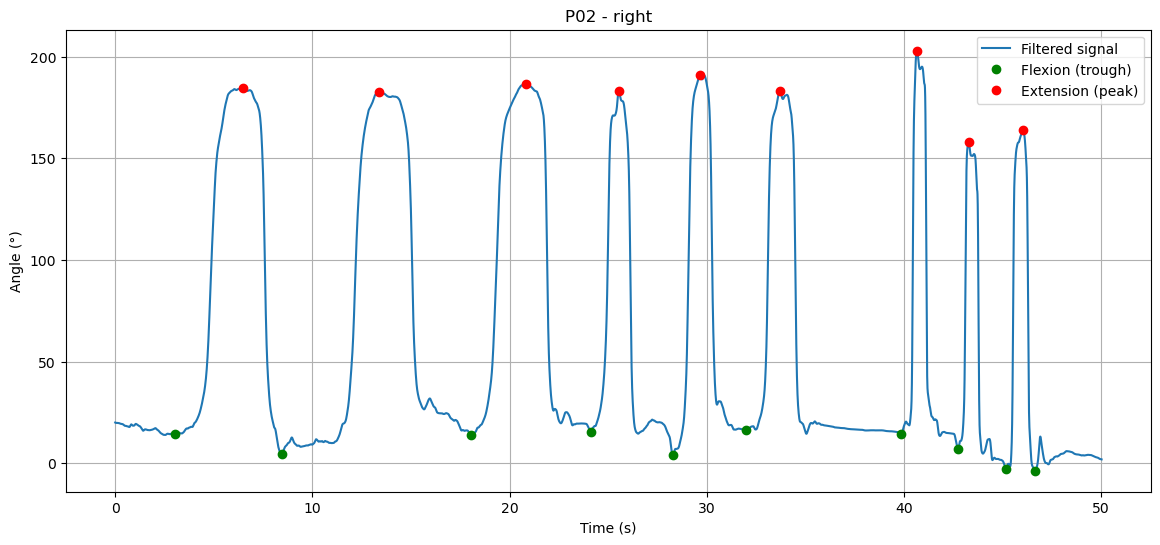


=== DETECTION: P02 | LEFT ===


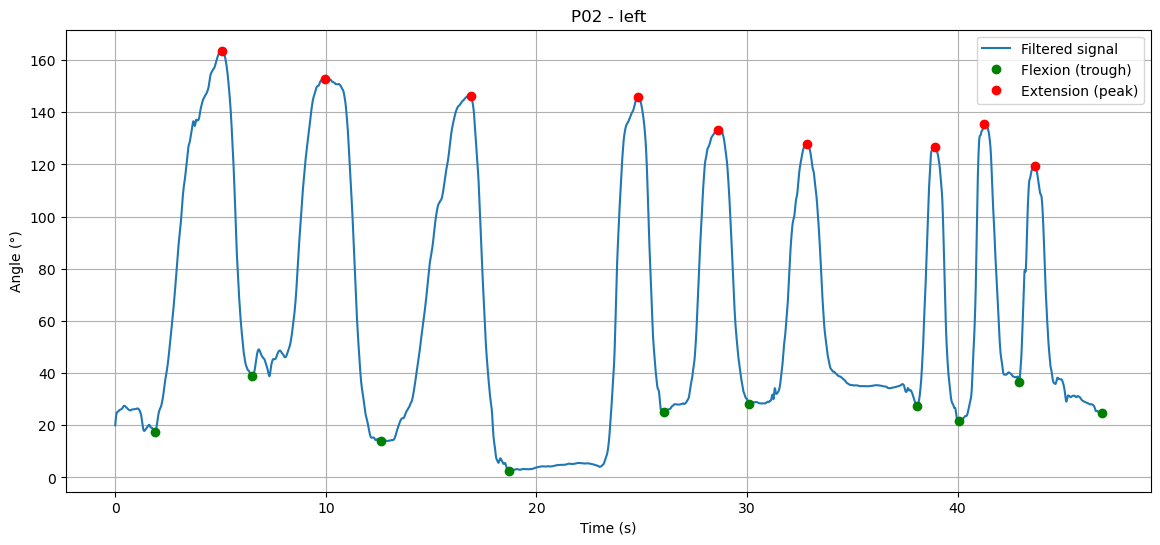


=== DETECTION: P03 | RIGHT ===


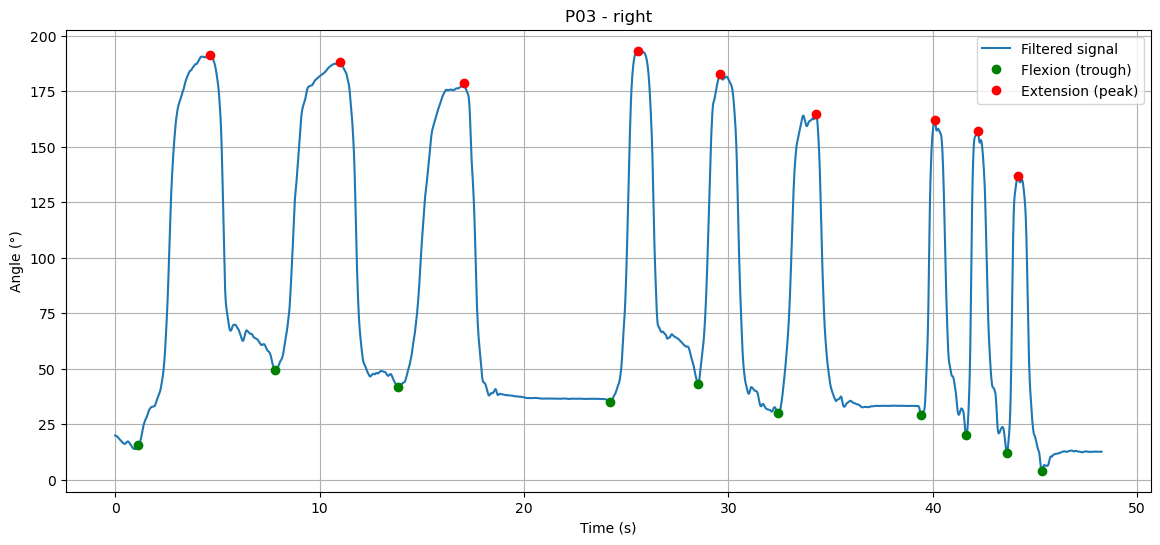


=== DETECTION: P03 | LEFT ===


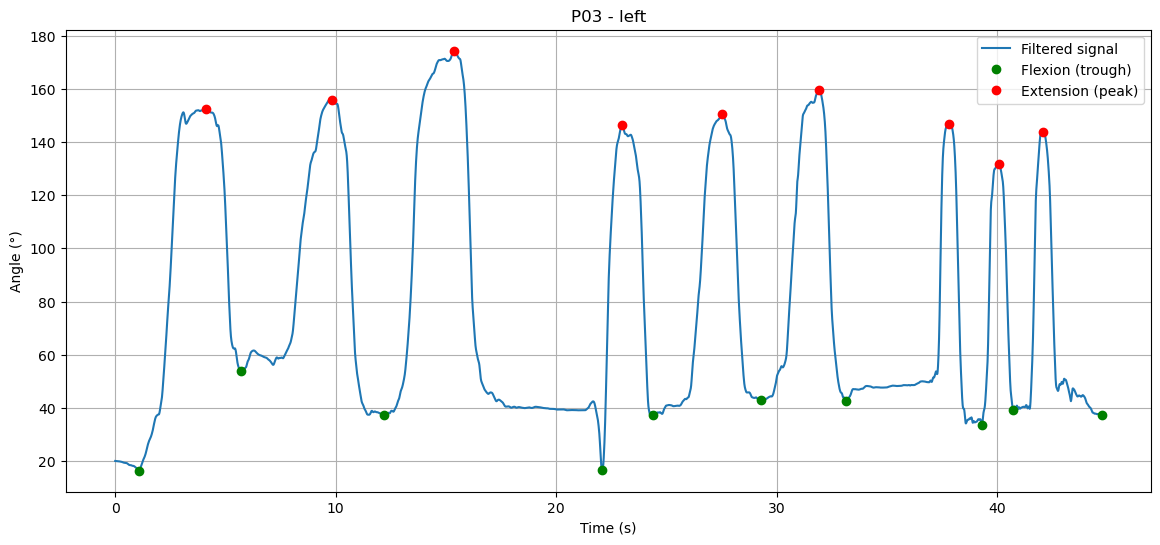


===== EVENTS: P01 | RIGHT =====
 event_id speed_category   velocity
        1           slow  52.614395
        2           slow  36.514885
        3           slow  43.429288
        4         medium 117.184722
        5         medium  64.361448
        6         medium  59.380786
        7           fast 161.487703
        8           fast 199.660161
        9           fast 120.097431


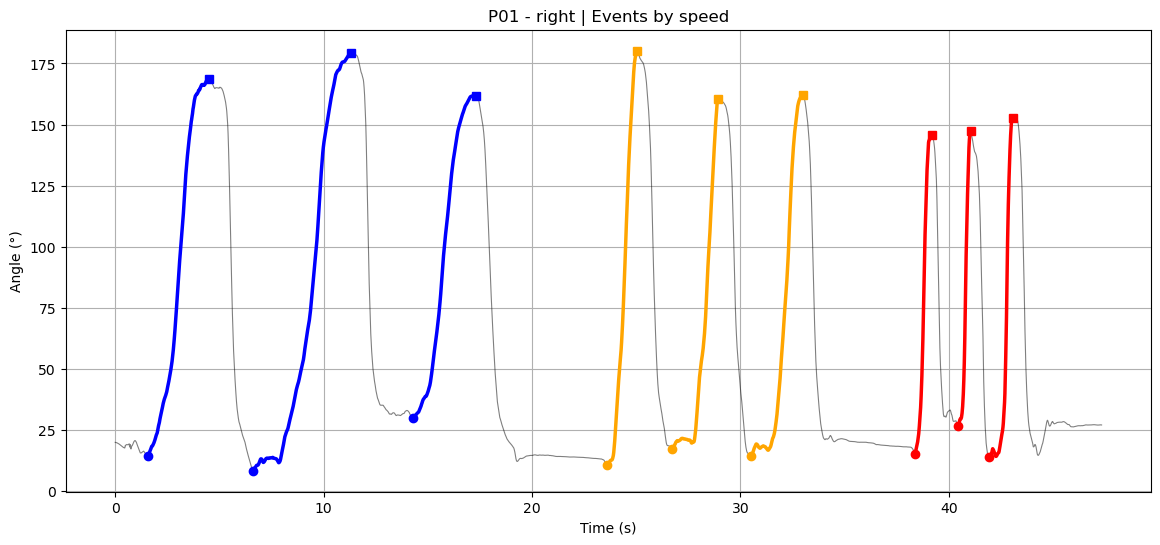


STATISTICS:

SLOW (n=3) : Mean velocity = 44.2 °/s

MEDIUM (n=3) : Mean velocity = 80.3 °/s

FAST (n=3) : Mean velocity = 160.4 °/s

===== EVENTS: P01 | LEFT =====
 event_id speed_category   velocity
        1           slow  90.446506
        2           slow  36.023943
        3           slow  69.561258
        4         medium  26.691929
        5         medium 164.057315
        6         medium  65.344362
        7           fast 238.189577
        8           fast 210.253353
        9           fast 196.849908


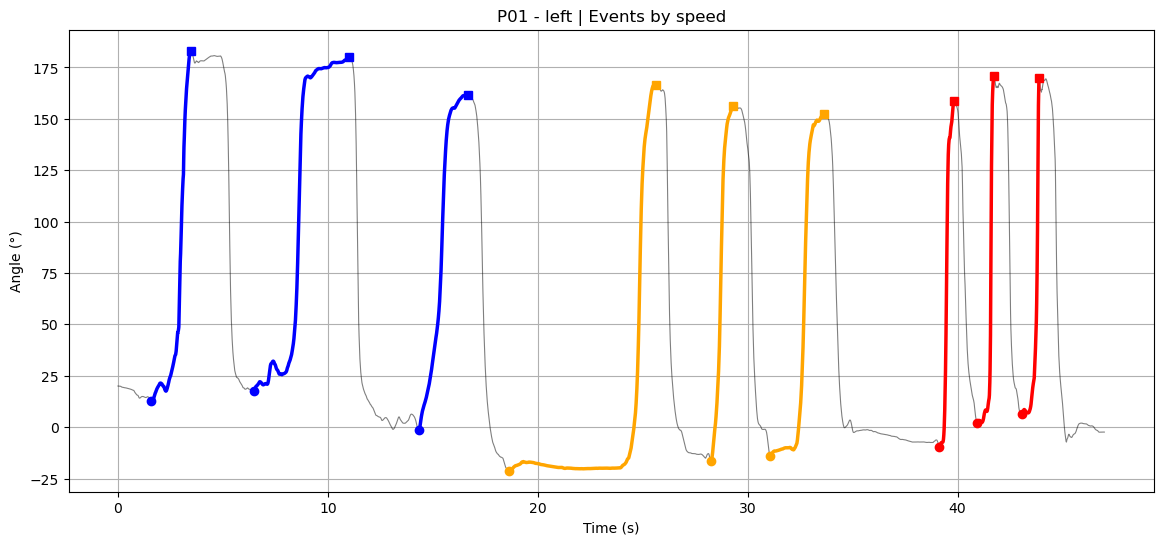


STATISTICS:

SLOW (n=3) : Mean velocity = 65.3 °/s

MEDIUM (n=3) : Mean velocity = 85.4 °/s

FAST (n=3) : Mean velocity = 215.1 °/s

===== EVENTS: P02 | RIGHT =====
 event_id speed_category   velocity
        1           slow  49.196038
        2           slow  36.205800
        3           slow  60.915454
        4         medium 117.695237
        5         medium 140.069235
        6         medium  96.297898
        7           fast 234.558522
        8           fast 283.100652
        9           fast 194.665156


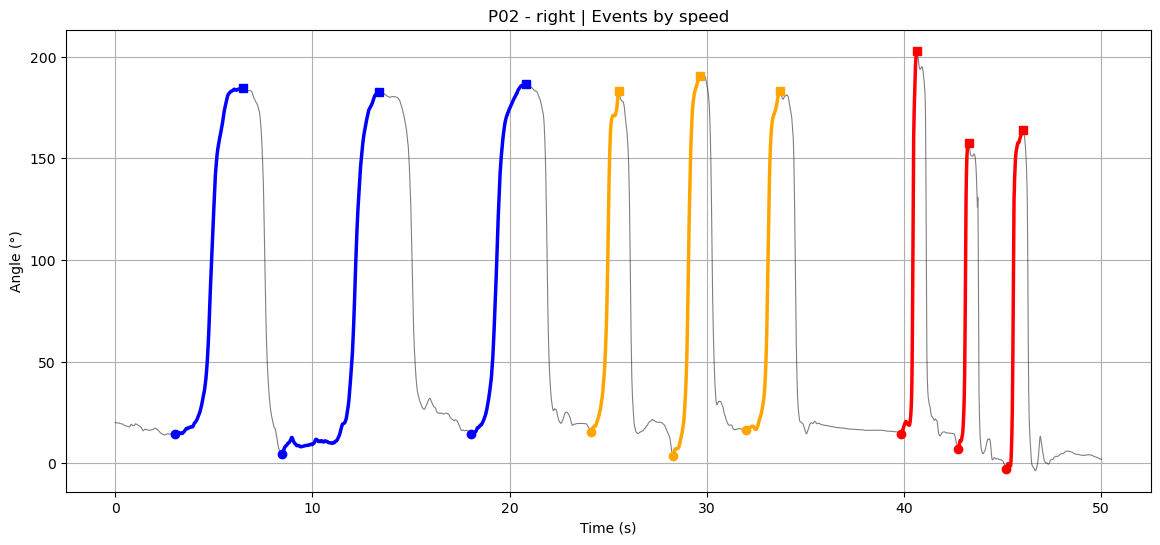


STATISTICS:

SLOW (n=3) : Mean velocity = 48.8 °/s

MEDIUM (n=3) : Mean velocity = 118.0 °/s

FAST (n=3) : Mean velocity = 237.4 °/s

===== EVENTS: P02 | LEFT =====
 event_id speed_category   velocity
        1           slow  46.008257
        2           slow  32.949972
        3           slow  31.088123
        4         medium  23.410910
        5         medium  42.743053
        6         medium  36.629674
        7           fast 114.645531
        8           fast  95.261052
        9           fast 113.785333


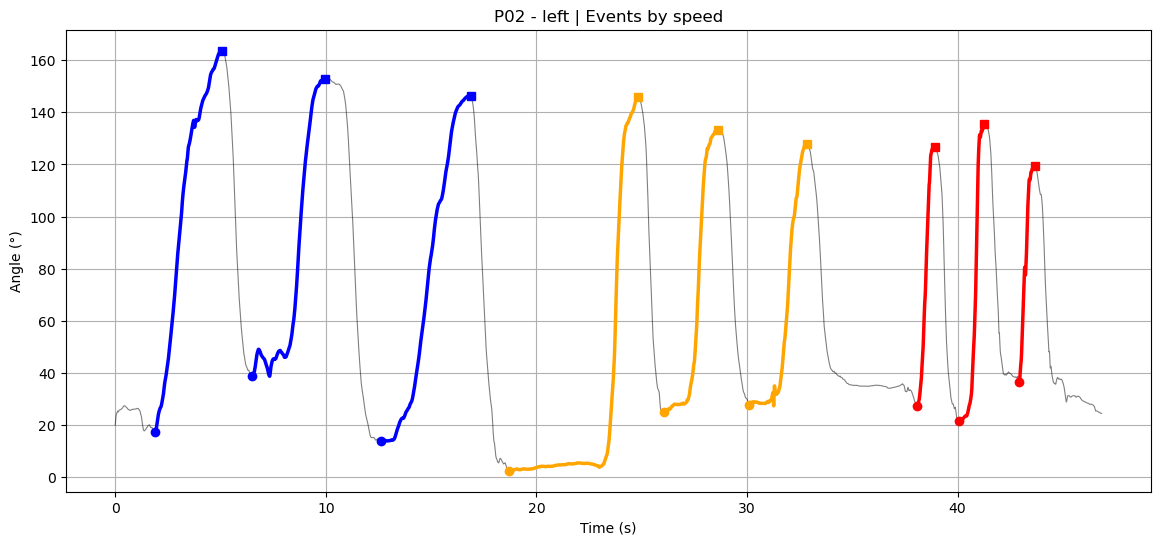


STATISTICS:

SLOW (n=3) : Mean velocity = 36.7 °/s

MEDIUM (n=3) : Mean velocity = 34.3 °/s

FAST (n=3) : Mean velocity = 107.9 °/s

===== EVENTS: P03 | RIGHT =====
 event_id speed_category   velocity
        1           slow  50.164378
        2           slow  43.811339
        3           slow  42.710784
        4         medium 118.086832
        5         medium 131.124061
        6         medium  73.660443
        7           fast 203.421723
        8           fast 246.190196
        9           fast 238.957739


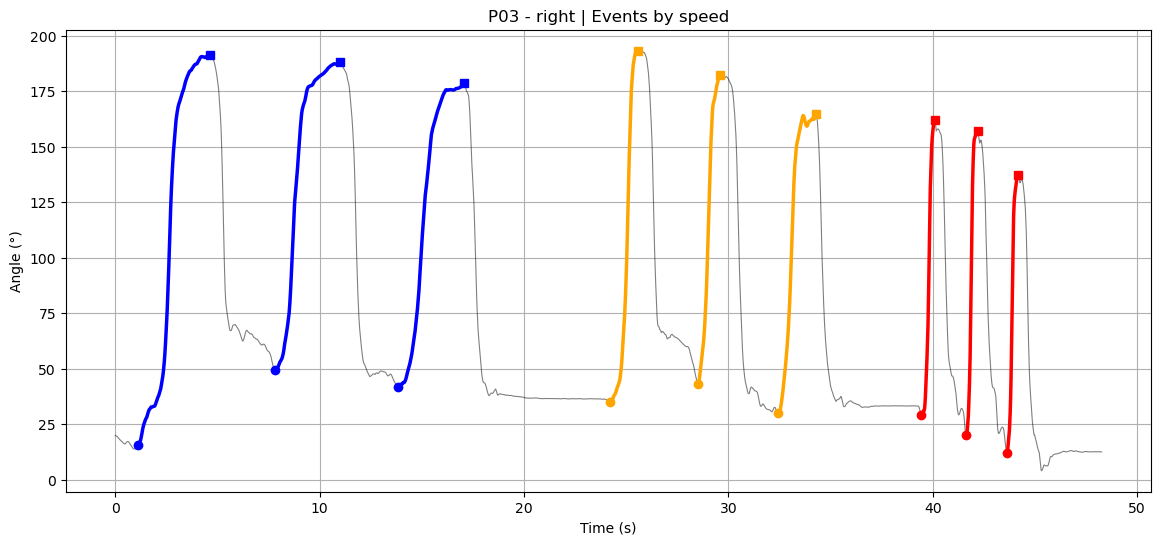


STATISTICS:

SLOW (n=3) : Mean velocity = 45.6 °/s

MEDIUM (n=3) : Mean velocity = 107.6 °/s

FAST (n=3) : Mean velocity = 229.5 °/s

===== EVENTS: P03 | LEFT =====
 event_id speed_category   velocity
        1           slow  44.991830
        2           slow  24.854320
        3           slow  43.394741
        4         medium 145.427347
        5         medium  36.271982
        6         medium  44.764875
        7           fast  22.404048
        8           fast 129.840265
        9           fast  77.478414


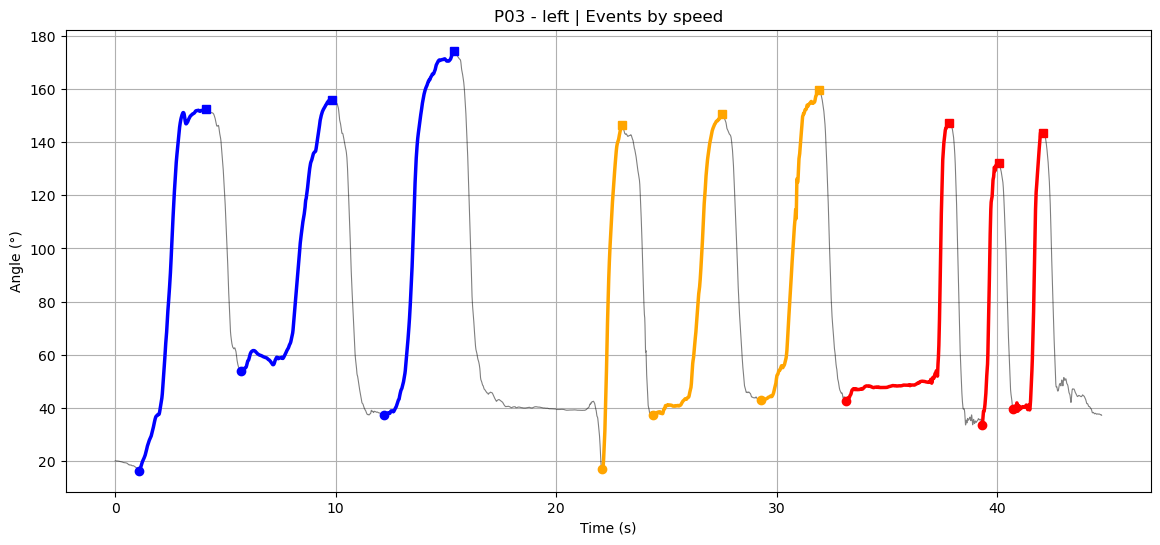


STATISTICS:

SLOW (n=3) : Mean velocity = 37.7 °/s

MEDIUM (n=3) : Mean velocity = 75.5 °/s

FAST (n=3) : Mean velocity = 76.6 °/s

PLOTTING REPRODUCIBILITY

REPRODUCIBILITY: P01 | right


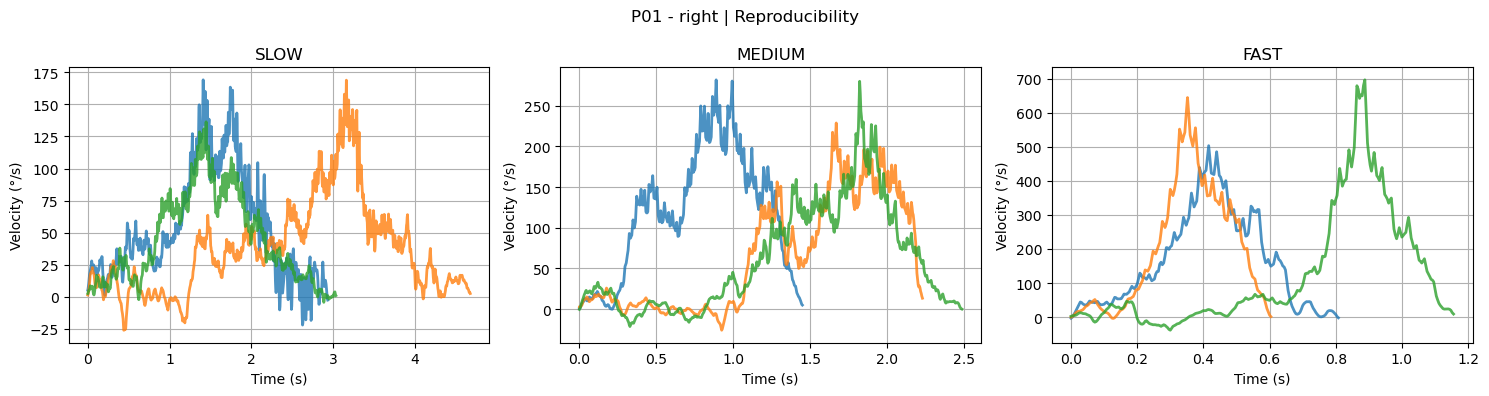


REPRODUCIBILITY: P01 | left


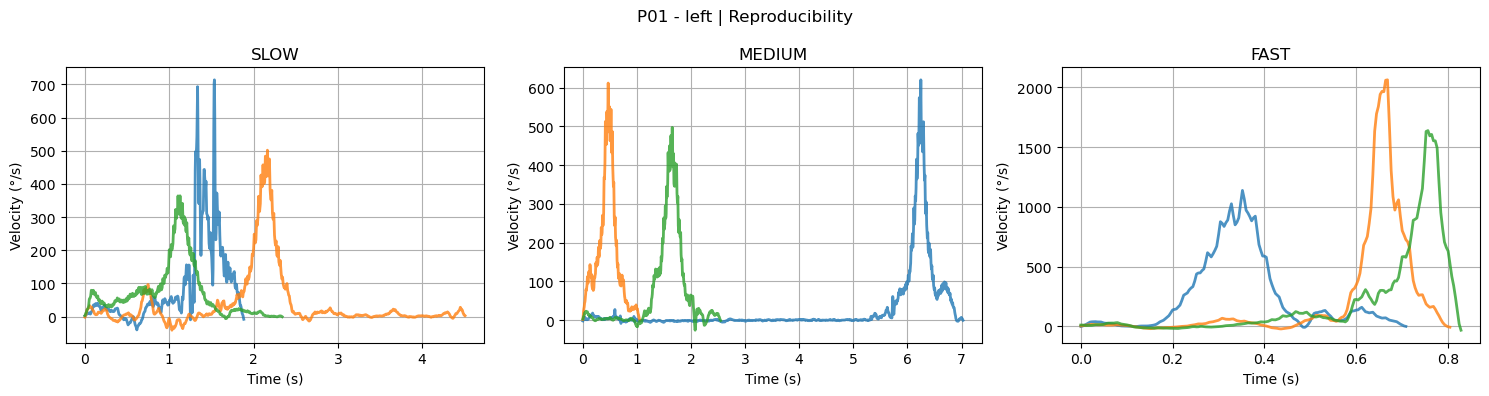


REPRODUCIBILITY: P02 | right


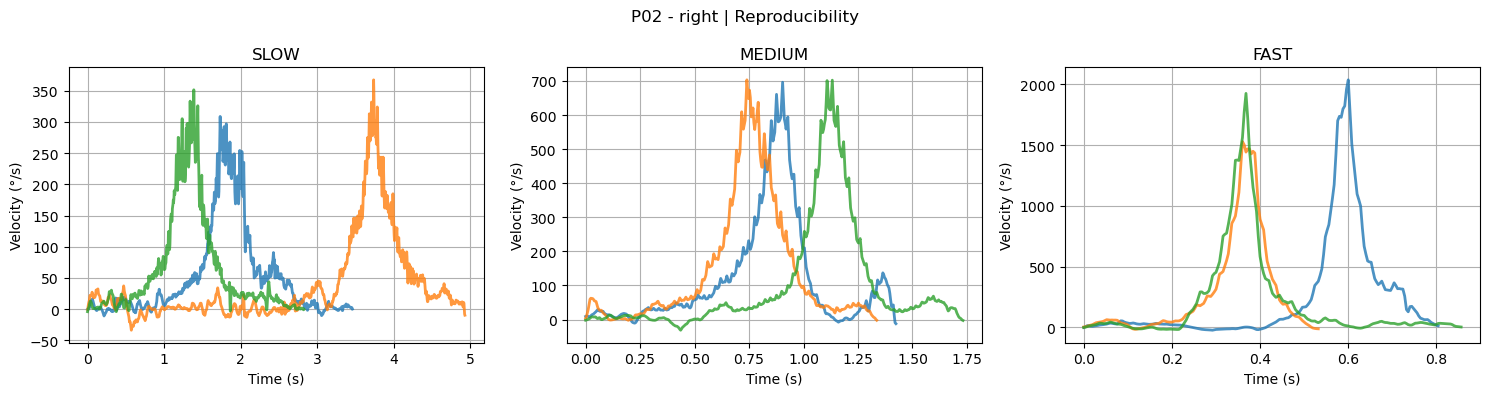


REPRODUCIBILITY: P02 | left


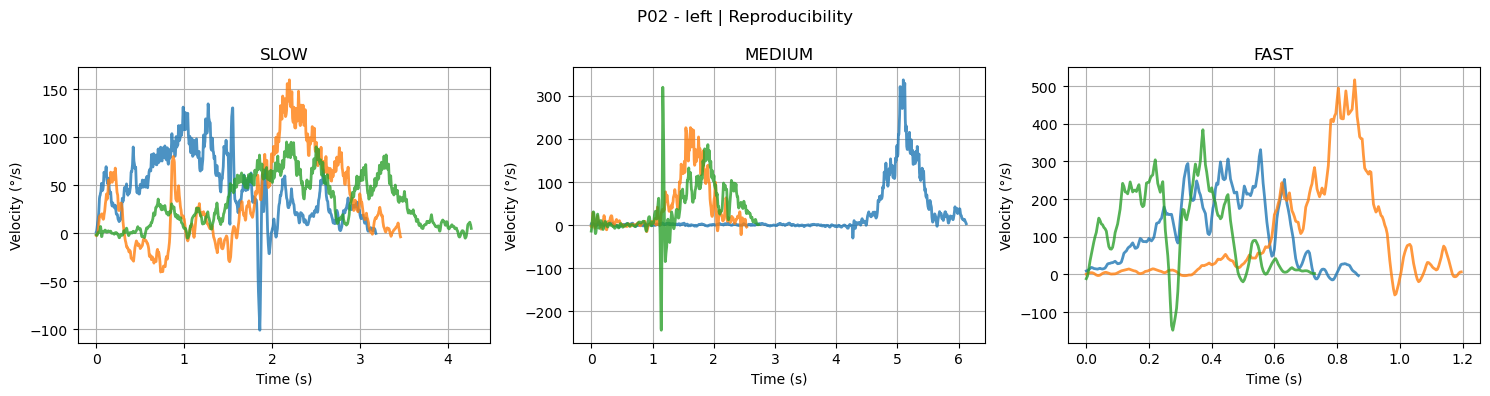


REPRODUCIBILITY: P03 | right


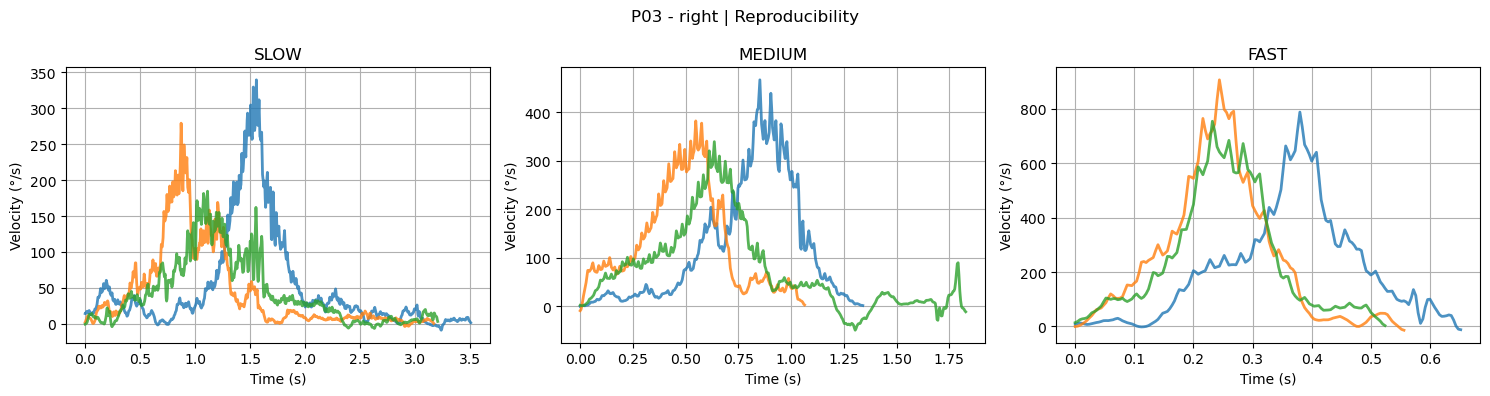


REPRODUCIBILITY: P03 | left


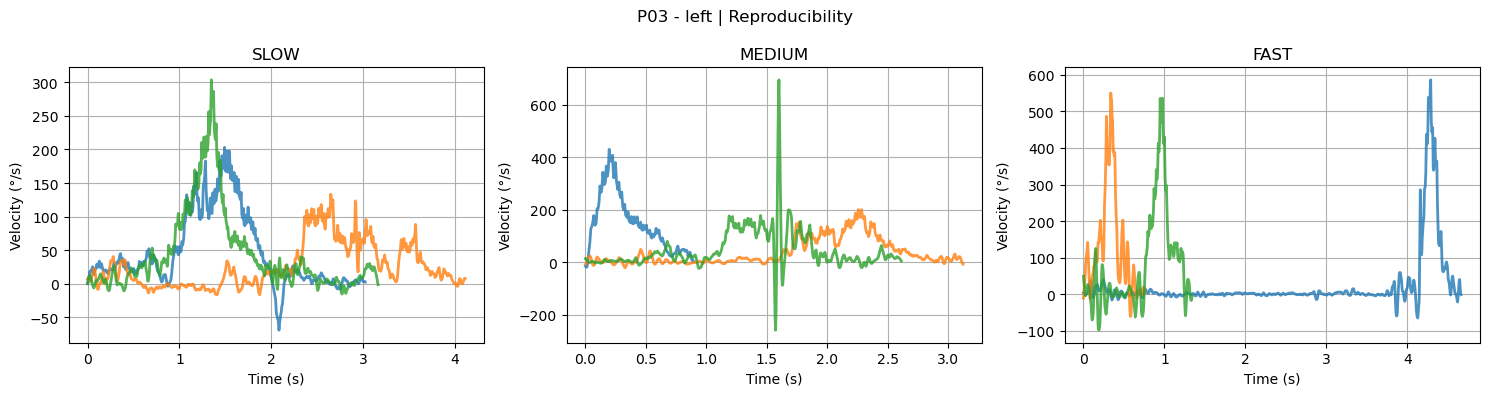

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX = 9        # max number of detected extension peaks
N_MIN = 10       # max number of detected flexion peaks
MIN_PROM = 15    # minimum prominence to detect a peak
MIN_DIST_SEC = 1.5  # minimum distance between two peaks (in seconds)
FILTER_CUTOFF = 10  # filter cutoff frequency (Hz)

# ==========================================================
# LOW-PASS FILTER
# ==========================================================
def filtrer_signal(signal, cutoff, fs):
    b, a = butter(4, min(cutoff / (0.5 * fs), 0.99), btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# EVENT DETECTION (peaks + troughs)
# ==========================================================
def detecter_evenements(df_angles):
    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))  # sampling frequency

    signal_f = filtrer_signal(angle, FILTER_CUTOFF, fs)
    dist = int(fs * MIN_DIST_SEC)

    # --- Peaks (extensions) ---
    pics, _ = find_peaks(signal_f, distance=dist, prominence=MIN_PROM)
    if len(pics) > N_MAX:
        pics = np.sort(pics[np.argsort(signal_f[pics])[::-1][:N_MAX]])

    # --- Troughs (flexions) ---
    creux = []
    for i in range(len(pics)):
        debut = int(max(0, pics[i] - 3.5 * fs)) if i == 0 else pics[i - 1]
        fin = pics[i]
        seg = signal_f[debut:fin]
        if len(seg) > 5:
            creux.append(debut + np.argmin(seg))

    # Trough after the last peak
    seg = signal_f[pics[-1]:]
    if len(pics) > 0 and len(seg) > 5:
        creux.append(pics[-1] + np.argmin(seg))

    creux = np.unique(creux)[:N_MIN]
    if len(creux) < N_MIN:
        creux = np.pad(creux, (0, N_MIN - len(creux)), mode='edge')

    return np.array(creux, dtype=int), pics, signal_f

# ==========================================================
# DISPLAY + STORAGE
# ==========================================================
def afficher_et_stocker(df_angles, creux, pics, signal_f, patient, cote, resultats):
    resultats.setdefault(patient, {})[cote] = {
        "angles": df_angles,
        "signal_filtre": signal_f,
        "flexions": creux,
        "extensions": pics
    }

    time = df_angles["time"].values
    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Filtered signal")
    if len(creux) > 0:
        plt.plot(time[creux], signal_f[creux], "go", label="Flexion (trough)")
    if len(pics) > 0:
        plt.plot(time[pics], signal_f[pics], "ro", label="Extension (peak)")
    plt.title(f"{patient} - {cote}")
    plt.xlabel("Time (s)"), plt.ylabel("Angle (°)")
    plt.legend(), plt.grid(), plt.show()

# ==========================================================
# MAIN LOOP: detection for all patients
# ==========================================================
resultats = {}
for patient, pdata in results.items():
    for cote, data in pdata.items():
        print(f"\n=== DETECTION: {patient} | {cote.upper()} ===")
        df_angles = quaternion_to_angle_y_calibrated(
            data["wrist"], data["baseline"]["wrist"], baseline_deg=20
        )
        creux, pics, signal_f = detecter_evenements(df_angles)
        afficher_et_stocker(df_angles, creux, pics, signal_f, patient, cote, resultats)

# ==========================================================
# EVENT ANALYSIS
# ==========================================================
COULEURS = {'slow': 'blue', 'medium': 'orange', 'fast': 'red', 'extra': 'gray'}
CATEGORIES = ['slow'] * 3 + ['medium'] * 3 + ['fast'] * 3

resume = {}
all_events_long = []

for patient, pdata in resultats.items():
    resume[patient] = {}
    for cote, data in pdata.items():
        print(f"\n===== EVENTS: {patient} | {cote.upper()} =====")

        signal = data["angles"]["angle"].values
        time   = data["angles"]["time"].values
        creux  = data["flexions"]
        pics   = data["extensions"]

        if len(creux) < 2 or len(pics) == 0:
            print("⚠️ Not enough peaks")
            continue

        # --- Event construction ---
        events = []
        for i in range(min(len(pics), len(creux) - 1)):
            t0, t1 = time[creux[i]], time[pics[i]]
            duree = t1 - t0
            amplitude = signal[pics[i]] - signal[creux[i]]
            events.append({
                'event_id': i + 1,
                'min_idx': creux[i], 'max_idx': pics[i],
                'speed_category': CATEGORIES[i] if i < len(CATEGORIES) else 'extra',
                'velocity': amplitude / duree if duree > 0 else 0,
                't_start': t0, 't_end': t1
            })
            all_events_long.append({
                'subject': patient, 'side': cote,
                'trial': i + 1,
                'speed': events[-1]['speed_category'],
                'velocity': events[-1]['velocity']
            })

        df_ev = pd.DataFrame(events)
        resume[patient][cote] = df_ev
        print(df_ev[['event_id', 'speed_category', 'velocity']].to_string(index=False))

        # --- Colored plot by speed ---
        plt.figure(figsize=(14, 6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)
        for ev in events:
            c = COULEURS[ev['speed_category']]
            idx = np.arange(ev['min_idx'], ev['max_idx'] + 1)
            plt.plot(time[idx], signal[idx], color=c, linewidth=2.5)
            plt.plot(time[ev['min_idx']], signal[ev['min_idx']], 'o', color=c)
            plt.plot(time[ev['max_idx']], signal[ev['max_idx']], 's', color=c)
        plt.title(f"{patient} - {cote} | Events by speed")
        plt.xlabel("Time (s)"), plt.ylabel("Angle (°)")
        plt.grid(True), plt.show()

        # --- Stats by category ---
        print("\nSTATISTICS:")
        for cat in ['slow', 'medium', 'fast']:
            subset = df_ev[df_ev['speed_category'] == cat]
            if len(subset) > 0:
                print(f"\n{cat.upper()} (n={len(subset)}) : Mean velocity = {subset['velocity'].mean():.1f} °/s")

# ==========================================================
# STEP 4 — REPRODUCIBILITY PLOTS
# ==========================================================

def extract_event_signal(df_angles, t_start, t_end):
    # Extract the signal segment between t_start and t_end
    mask = (df_angles["time"] >= t_start) & (df_angles["time"] <= t_end)
    t = df_angles.loc[mask, "time"].values
    angle = df_angles.loc[mask, "angle"].values

    if len(t) < 2:
        return None, None  # Not enough data

    t_rel = t - t[0]  # Relative time starting at 0 (in seconds)
    velocity = np.gradient(angle, t)
    return t_rel, velocity


def plot_reproducibility(events_results, all_events_summary):
    speeds = ["slow", "medium", "fast"]

    for patient in all_events_summary:
        for side in all_events_summary[patient]:
            print(f"\nREPRODUCIBILITY: {patient} | {side}")

            df_events = all_events_summary[patient][side]
            df_angles = events_results[patient][side]["angles"]

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))

            for ax, speed in zip(axes, speeds):
                subset = df_events[df_events["speed_category"] == speed]

                if subset.empty:
                    ax.set_title(f"{speed.upper()} (no data)")
                    continue

                for _, ev in subset.iterrows():
                    t_rel, velocity = extract_event_signal(df_angles, ev["t_start"], ev["t_end"])
                    if t_rel is not None:
                        ax.plot(t_rel, velocity, linewidth=2, alpha=0.8)

                ax.set_title(speed.upper())
                ax.set_xlabel("Time (s)")  # Real time in seconds
                ax.set_ylabel("Velocity (°/s)")
                ax.grid(True)

            plt.suptitle(f"{patient} - {side} | Reproducibility")
            plt.tight_layout()
            plt.show()


# ==========================================================
# CALL THE FUNCTION
# ==========================================================
print("\n" + "="*60)
print("PLOTTING REPRODUCIBILITY")
print("="*60)

plot_reproducibility(events_results, all_events_summary)




## Data Export — Preparing the Dataset for Statistical Analysis

### Objective
Clean, standardise, and export the velocity dataset so it is ready
for the reproducibility analysis (ICC) performed in R.

### What this cell does
- Renames and harmonises column labels to English (`speed_category` → `speed`,
  `lente` → `slow`, `moyenne` → `medium`, `rapide` → `fast`)
- Numbers each trial within each group (patient × side × speed): trial 1, 2, 3
- Exports the final table as `velocity_trials_clean.csv`

### Output
A clean CSV file with one row per trial and the following columns:

| Column       | Description                              |
|--------------|------------------------------------------|
| `patient_id` | Patient identifier                       |
| `side`       | Limb side (`right` / `left`)             |
| `speed`      | Speed condition (`slow`/`medium`/`fast`) |
| `trial`      | Trial number within each group (1–3)     |
| `velocity`   | Mean angular velocity (°/s)              |

> This file is the direct input to (R — ICC analysis).

In [40]:
# ==========================================================
# CLEAN + STANDARDISE COLUMN NAMES (ENGLISH)
# ==========================================================

df_full = df_full.rename(columns={
    "speed_category": "speed"
})

# Harmonise names
df_full["speed"] = df_full["speed"].replace({
    "lente": "slow",
    "moyenne": "medium",
    "rapide": "fast"
})

# ==========================================================
# ADD TRIAL NUMBER PER SPEED
# ==========================================================

df_full = df_full.sort_values(by=["patient_id", "side", "speed"])

df_full["trial"] = (
    df_full
    .groupby(["patient_id", "side", "speed"])
    .cumcount() + 1
)

# Export
df_full.to_csv("velocity_trials_clean.csv", index=False)

print("✅ CSV ready for ICC")
print(df_full.head())

✅ CSV ready for ICC
   patient patient_id  side  event_id   speed  velocity  trial
51     P03         Ca  left         7    fast     22.40      1
52     P03         Ca  left         8    fast    129.84      2
53     P03         Ca  left         9    fast     77.48      3
48     P03         Ca  left         4  medium    145.43      1
49     P03         Ca  left         5  medium     36.27      2
